<a href="https://colab.research.google.com/github/SebastianGustavoRojasPeralta/SIS420RojasPeraltaSebastian/blob/main/Laboratorios/Laboratorio03/Laboratorio03Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Laboratorio 03: Clasificación mediante Regresión Logística**

**Nombre:** Sebastian Gustavo Rojas Peralta
**Dataset:** Online News Popularity

Este cuadernillo implementa un modelo de **Regresión Logística Binaria** para resolver un problema de clasificación. A diferencia de la regresión lineal que predice valores continuos, este modelo utiliza la función Sigmoide para calcular la probabilidad de que un ejemplo pertenezca a una clase discreta (0 o 1).

Para garantizar la validez del modelo y evitar el sobreajuste, el dataset será procesado con pandas y dividido bajo el principio de: 80% de los datos se utilizarán exclusivamente para entrenar el modelo, y el 20% restante se mantendrá oculto para realizar las pruebas de efectividad finales.

**Preparación y limpieza de datos**

Para este laboratorio de clasificación, utilicé el dataset de popularidad de noticias de Mashable. Para que el modelo funcione correctamente, realicé los siguientes pasos de limpieza con pandas:

1. **Lectura y Limpieza Automática:** Cargué el archivo usando pd.read_csv. Como este dataset es bastante pesado, Pandas me permite manejar los datos de forma mucho más fluida que numpy. Además, usé .fillna(0) para asegurarme de que no existiera ningún valor nulo que pudiera romper los cálculos matemáticos.

2. **Selección de Características Relevantes:** El dataset original tiene 61 columnas, pero las dos primeras son informativas y no son números que el modelo pueda usar para aprender. Por eso, filtré el dataframe para empezar desde la columna 2 en adelante, dejando fuera los datos no numéricos.

3. **Transformación de Regresión a Clasificación:** Este dataset originalmente trae el número exacto de veces que se compartió una noticia. Como mi objetivo es realizar una **Clasificación Binaria**, convertí esos números en categorías: si una noticia tiene más de 1400 compartidos, la etiqueté como **Popular (1)**; de lo contrario, se etiqueta como **No Popular (0)**.

4. **Estructura para el Modelo:** Finalmente, separé mis variables independientes ($X$) de mi nueva etiqueta binaria ($y$) y agregué la columna de unos para el término de sesgo ($\theta_0$).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import optimize
%matplotlib inline

ruta_archivo = '/content/drive/MyDrive/machine learning/datsets/OnlineNewsPopularity.csv'

# Carga con pandas
df = pd.read_csv(ruta_archivo)

# Limpieza preventiva de valores nulos
df = df.fillna(0)

# Seleccion de la columnas
#
# .iloc[:, 2:] toma todas las filas y desde la columna índice 2 hasta el final
data_filtrada = df.iloc[:, 2:]

# separar x y y
# X son todas las columnas menos la última
X = data_filtrada.iloc[:, :-1].values

# y_original es la última columna
y_original = data_filtrada.iloc[:, -1].values

# Truco de clasificacion (Umbral de 1400)
# Convertimos a 1 si es popular y 0 si no lo es
y = np.where(y_original > 1400, 1, 0)

m = y.size
print(f"Dataset cargado con Pandas: {m} ejemplos con {X.shape[1]} características.")

# Columna de unos
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print("Matriz X lista con columna de unos agregada.")
print(f"Primeros 5 valores de y (Popularidad): {y[:5]}")

Dataset cargado con Pandas: 39644 ejemplos con 58 características.
Matriz X lista con columna de unos agregada.
Primeros 5 valores de y (Popularidad): [0 0 1 0 0]


**La Función Sigmoide**

Como estamos pasando de predecir números a predecir categorías, ya no nos sirve una línea recta que crece hasta el infinito. Necesitamos "aplastar" nuestros resultados.

El trabajo de la funcion sigmoide es recibir cualquier número y transformarlo en un valor entre **0 y 1**.

Esto es clave porque en Machine Learning interpretamos ese resultado como una probabilidad:
* Si la sigmoide nos da **0.85**, significa que hay un 85% de probabilidad de que la noticia sea popular.
* Si nos da **0.10**, solo hay un 10% de probabilidad (es decir, casi seguro es "No Popular").

Básicamente, la sigmoide actúa como un filtro que decide en qué grupo cae cada noticia.

In [3]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la entrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

# Prueba la implementacion de la funcion sigmoid
# Usamos los mismos valores de prueba del ingeniero
z_prueba = [-100, 0.5, 1000000]
g = sigmoid(z_prueba)

print('g(', z_prueba, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


**Optimización del Modelo: Costo y Gradiente**

Para que nuestro clasificador de noticias aprenda, necesitamos dos componentes trabajando juntos en el código:

1. **La función calcularCosto:** Es nuestro termómetro. Nos dice qué tan lejos estamos de la realidad. Si el modelo dice que una noticia es popular pero en realidad no lo fue, esta función devuelve un número alto.
2. **El algoritmo de descensoGradiente:** Es el que hace el trabajo duro. Utiliza el resultado del costo para saber hacia dónde ajustar los pesos (Thetas).
Tambien he modificado el Gradiente para que no solo nos dé el error matemático, sino que también calcule en cada paso el **porcentaje de aciertos**. Así podemos ver en tiempo real cómo la precisión del modelo sube mientras el error baja.

In [4]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    # El truco del 1e-15 para evitar el error de log(0)
    J = (1 / m) * np.sum(-y.dot(np.log(h + 1e-15)) - (1 - y).dot(np.log(1 - h + 1e-15)))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    p_historico = []

    for i in range(num_iters):
        #Cálculo de la predicción y actualización de Thetas
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        #se guarda el costo de esta iteracion
        J_history.append(calcularCosto(theta, X, y))

        #Evaluación de precisión
        p_actual = np.round(sigmoid(X.dot(theta.T)))
        aciertos = np.sum(p_actual == y)
        porcentaje_aciertos = (aciertos / m) * 100
        p_historico.append(porcentaje_aciertos)

    return theta, J_history, p_historico

**Validación de las funciones de Costo y Gradiente**

Antes de proceder con la división del dataset y el entrenamiento completo, es una buena práctica realizar una prueba unitaria de nuestras funciones.

Evaluamos el modelo con los parámetros inicializados en cero. Matemáticamente, si el modelo no tiene ninguna inclinación (Thetas en cero), la función de costo debería devolver el logaritmo natural de 0.5, que es aproximadamente **0.693**. Si el resultado coincide, confirmamos que la implementación de la Sigmoide es correcta.

In [5]:
def costFunction(theta, X, y):
    m = y.size
    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    # Aplicamos la fórmula y el pequeño truco para evitar log(0)
    J = (1 / m) * np.sum(-y.dot(np.log(h + 1e-15)) - (1 - y).dot(np.log(1 - h + 1e-15)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

# Prueba de validación rápida
initial_theta = np.zeros(X.shape[1])
cost, grad = costFunction(initial_theta, X, y)

print('PRUEBA DE FUNCIONAMIENTo')
print('Costo en theta inicial (ceros): {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.693\n')

print('Gradiente en theta inicial (primeros 5 valores):')
print(grad[:5])

PRUEBA DE FUNCIONAMIENTo
Costo en theta inicial (ceros): 0.693
Costo esperado (aproximado): 0.693

Gradiente en theta inicial (primeros 5 valores):
[ 6.55836949e-03  1.14166078e-01 -5.91501867e+00 -2.08238277e-03
 -5.07012417e-03]


**Entrenamiento del Modelo y Validación con Datos Ocultos (80/20)**


1. **División 80/20:** Mezclamos el dataset aleatoriamente y guardamos un 20% de las noticias en una "bóveda" (X_test). El modelo nunca verá estas noticias durante el entrenamiento.
2. **Normalización:** Como las columnas del dataset de noticias tienen escalas muy diferentes (unas son de 0 a 1 y otras son de miles), normalizamos los datos para que el Descenso por Gradiente pueda bajar directo al mínimo sin dar vueltas innecesarias.
3. **Entrenamiento:** Usamos el 80% de los datos para encontrar los mejores Thetas.
4. **Prueba de Fuego:** Usamos el 20% guardado para ver cuántas noticias populares logra adivinar el modelo en el "mundo real".

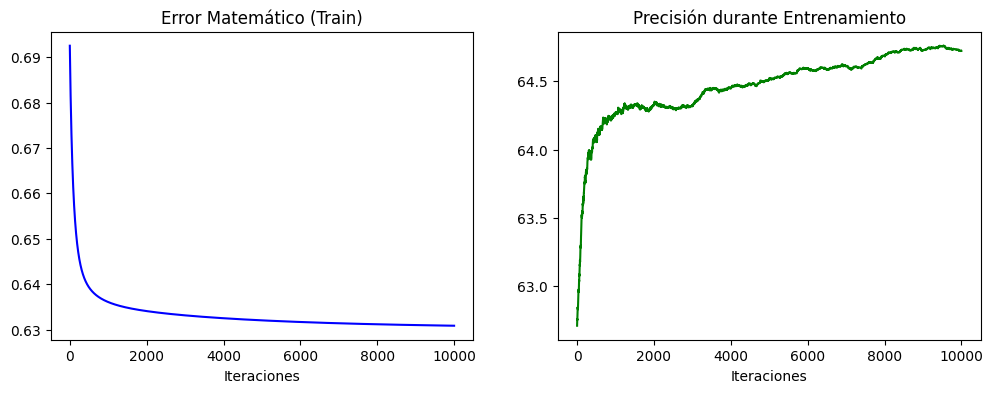

RESULTADO
Efectividad real demostrada con datos nuevos: 65.80%


In [14]:
# MEZCLADO Y DIVISIÓN 80/20
m_total = y.size
indices = np.random.permutation(m_total)
limite_80 = int(0.8 * m_total)

# Creamos los sets de Entrenamiento (80%) y Prueba (20%)
X_train, y_train = X[indices[:limite_80]], y[indices[:limite_80]]
X_test, y_test = X[indices[limite_80:]], y[indices[limite_80:]]

# NORMALIZACIÓN
# Calculamos media y desviación SOLO del set de entrenamiento
mu = np.mean(X_train[:, 1:], axis=0)
sigma = np.std(X_train[:, 1:], axis=0)

X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

# Aplicamos la escala a ambos
X_train_norm[:, 1:] = (X_train[:, 1:] - mu) / (sigma + 1e-15)
X_test_norm[:, 1:] = (X_test[:, 1:] - mu) / (sigma + 1e-15)

# ENTRENAMIENTO (Solo con el 80%)
alpha = 0.01
num_iters = 10000
theta_inicial = np.zeros(X_train_norm.shape[1])

# Llamamos a tu función de gradiente
theta_final, J_history, p_historico = descensoGradiente(theta_inicial, X_train_norm, y_train, alpha, num_iters)

# GRÁFICAS DE APRENDIZAJE
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(J_history, color='blue')
plt.title('Error Matemático (Train)')
plt.xlabel('Iteraciones')

plt.subplot(1, 2, 2)
plt.plot(p_historico, color='green')
plt.title('Precisión durante Entrenamiento')
plt.xlabel('Iteraciones')
plt.show()

# VALIDACIÓN FINAL
# Aquí usamos el X_test_norm y los thetas que aprendimos
probabilidades_finales = sigmoid(X_test_norm.dot(theta_final.T))
predicciones_finales = np.round(probabilidades_finales)

# Calculamos la efectividad real
aciertos = np.sum(predicciones_finales == y_test)
efectividad = (aciertos / y_test.size) * 100

print(f"RESULTADO")
print(f"Efectividad real demostrada con datos nuevos: {efectividad:.2f}%")

**Paramentros de aprendizaje usando scipy.optimize**

En el código anterior se encontró los parámetros óptimos de un modelo al implementar el descenso de gradiente iterativo.En lugar de realizar los pasos del descenso por el gradiente manualmente, se utilizará el módulo scipy.optimize. SciPy es una biblioteca de computación numérica para Python que proporciona módulos de optimización para la búsqueda y minimización de raíces. Utilizamos la función scipy.optimize.minimize con el algoritmo de Newton Truncado (TNC).Al usar optimize.minimize, no hay necesidad de escribir bucles ni de establecer empíricamente una tasa de aprendizaje ($\alpha$). Solo se necesita proporcionar una función que calcule simultáneamente el costo y el gradiente exacto.

In [7]:
# Configuración de opciones
# maxiter: 1000 iteraciones es un buen límite para asegurar convergencia
options = {'maxiter': 1000}

# Ejecución de la optimización
# IMPORTANTE: Usamos X_train_norm e y_train (el 80%)
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_train_norm, y_train),
                        jac=True,
                        method='TNC',
                        options=options)

# Extraemos los resultados
costo_scipy = res.fun
theta_scipy = res.x

print('Costo final (Scipy): {:.3f}'.format(costo_scipy))
print('¿La optimización fue exitosa?:', res.success)

# VALIDACIÓN DE EFECTIVIDAD
# Usamos el 20% de prueba que el optimizador NUNCA vio
probabilidades_scipy = sigmoid(X_test_norm.dot(theta_scipy.T))
predicciones_scipy = np.round(probabilidades_scipy)

# Calculamos la precisión final
aciertos_scipy = np.sum(predicciones_scipy == y_test)
efectividad_scipy = (aciertos_scipy / y_test.size) * 100

print(f"\n--- VALIDACIÓN FINAL ---")
print(f"Efectividad con Scipy sobre datos de prueba: {efectividad_scipy:.2f}%")

/tmp/ipykernel_335/867567833.py:7: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,


Costo final (Scipy): 0.627
¿La optimización fue exitosa?: True

--- VALIDACIÓN FINAL ---
Efectividad con Scipy sobre datos de prueba: 64.81%


**Evaluación de la Efectividad del Modelo**

Para finalizar, implementamos la función predict, que actúa como el motor de decisión del modelo. Esta función toma las probabilidades generadas por la sigmoide y las convierte en una respuesta binaria: **1 (Popular)** si la probabilidad es igual o mayor al 50%, y **0 (No Popular)** en caso contrario.

A diferencia de las pruebas tradicionales, evaluamos la exactitud del modelo utilizando el **conjunto de prueba (20%)**. Estos son datos que el optimizador nunca procesó, por lo que el resultado refleja la capacidad real del modelo para generalizar ante nuevas noticias en el mundo real.

In [8]:
def predict(theta, X):
    """
    Calcula las predicciones para X usando un umbral en 0.5
    """
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

# EVALUACIÓN DE LA PRECISIÓN REAL

# Usamos los thetas de Scipy y el set que guardamos para el examen (X_test_norm)
p_test = predict(theta_scipy, X_test_norm)

# Calculamos la precisión comparando con las etiquetas reales que no usamos
exactitud_test = np.mean(p_test == y_test) * 100

print(f'Efectividad real del modelo (con datos desconocidos): {exactitud_test:.2f} %')


#PREDICCIÓN INDIVIDUAL (Caso de prueba)

# Por ahora, tomamos el primer ejemplo del set de prueba para ver qué predice.
ejemplo_X = X_test_norm[0, :].reshape(1, -1)
ejemplo_y = y_test[0]

prediccion_individual = predict(theta_scipy, ejemplo_X)
probabilidad_individual = sigmoid(ejemplo_X.dot(theta_scipy.T))

print(f'\n--- Prueba Individual ---')
print(f'Probabilidad calculada: {probabilidad_individual[0]*100:.2f}%')
print(f'Predicción del modelo: {"Popular" if prediccion_individual[0] == 1 else "No Popular"}')
print(f'Valor real en el dataset: {"Popular" if ejemplo_y == 1 else "No Popular"}')

Efectividad real del modelo (con datos desconocidos): 64.81 %

--- Prueba Individual ---
Probabilidad calculada: 41.63%
Predicción del modelo: No Popular
Valor real en el dataset: No Popular
